In [105]:
# Import necessary libraries
import sys
import matplotlib
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, confusion_matrix, classification_report

# Loading the dataset
df = pd.read_csv("health_activity_data.csv")

In [107]:
# Print versions for report
print("Python version:", sys.version)
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("Seaborn version:", sns.__version__)
print("Scikit-learn version:", sklearn.__version__)

Python version: 3.11.5 (main, Sep 11 2023, 08:31:25) [Clang 14.0.6 ]
Pandas version: 2.0.3
NumPy version: 1.24.3
Matplotlib version: 3.7.2
Seaborn version: 0.12.2
Scikit-learn version: 1.6.1


# Inspecting the Dataset

In [7]:
# Preview data
df.head()

,ID,Age,Gender,Height_cm,Weight_kg,BMI,Daily_Steps,Calories_Intake,Hours_of_Sleep,Heart_Rate,Blood_Pressure,Exercise_Hours_per_Week,Smoker,Alcohol_Consumption_per_Week,Diabetic,Heart_Disease
0,1,56,Male,164,81,30.72,5134,1796,8.6,102,137/72,8.1,No,7,No,No
1,2,69,Male,156,82,20.86,12803,1650,4.5,103,129/65,3.7,No,7,No,No
2,3,46,Female,158,65,30.93,16408,1756,4.3,74,127/68,3.2,Yes,0,No,No
3,4,32,Male,197,87,31.19,18420,2359,4.1,116,125/86,8.5,No,5,No,No
4,5,60,Male,157,63,29.37,17351,2556,5.1,111,100/64,8.5,Yes,8,No,No


In [8]:
# check for any missing values
df.isnull().sum()

ID                              0
Age                             0
Gender                          0
Height_cm                       0
Weight_kg                       0
BMI                             0
Daily_Steps                     0
Calories_Intake                 0
Hours_of_Sleep                  0
Heart_Rate                      0
Blood_Pressure                  0
Exercise_Hours_per_Week         0
Smoker                          0
Alcohol_Consumption_per_Week    0
Diabetic                        0
Heart_Disease                   0
dtype: int64

In [9]:
#get first look at data with summary
df.describe()

,ID,Age,Height_cm,Weight_kg,BMI,Daily_Steps,Calories_Intake,Hours_of_Sleep,Heart_Rate,Exercise_Hours_per_Week,Alcohol_Consumption_per_Week
count,1000.000000,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,49.857000,174.74500,84.35200,26.729510,10717.034000,2327.117000,6.90990,84.710000,5.045500,4.573000
std,288.819436,18.114267,14.54192,20.06596,4.786341,5444.707891,657.847942,1.77964,20.130155,2.847801,2.852509
min,1.000000,18.000000,150.00000,50.00000,18.500000,1016.000000,1201.000000,4.00000,50.000000,0.000000,0.000000
25%,250.750000,35.000000,162.00000,68.00000,22.600000,6028.250000,1745.750000,5.30000,67.000000,2.675000,2.000000
50%,500.500000,50.000000,175.00000,84.00000,26.800000,10898.000000,2328.500000,6.90000,84.000000,5.100000,5.000000
75%,750.250000,66.000000,187.00000,101.00000,30.850000,15253.250000,2880.000000,8.40000,103.000000,7.600000,7.000000
max,1000.000000,79.000000,199.00000,119.00000,34.980000,19931.000000,3498.000000,10.00000,119.000000,10.000000,9.000000


In [10]:
# Find data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            1000 non-null   int64  
 1   Age                           1000 non-null   int64  
 2   Gender                        1000 non-null   object 
 3   Height_cm                     1000 non-null   int64  
 4   Weight_kg                     1000 non-null   int64  
 5   BMI                           1000 non-null   float64
 6   Daily_Steps                   1000 non-null   int64  
 7   Calories_Intake               1000 non-null   int64  
 8   Hours_of_Sleep                1000 non-null   float64
 9   Heart_Rate                    1000 non-null   int64  
 10  Blood_Pressure                1000 non-null   object 
 11  Exercise_Hours_per_Week       1000 non-null   float64
 12  Smoker                        1000 non-null   object 
 13  Alco

# Data Visualizations

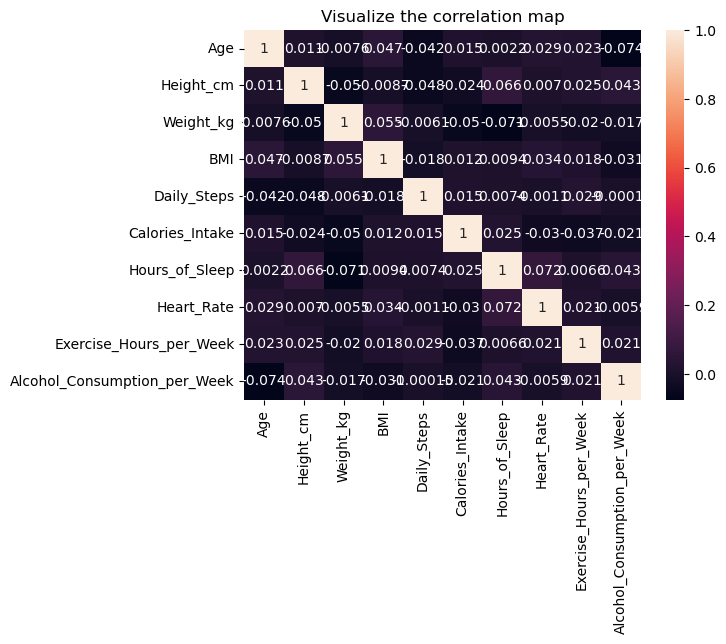

In [12]:
# Visualize the Correlation map
corr=df[['Age','Height_cm','Weight_kg','BMI','Daily_Steps','Calories_Intake','Hours_of_Sleep','Heart_Rate','Exercise_Hours_per_Week','Alcohol_Consumption_per_Week']].corr()
sns.heatmap(corr,annot=True)
plt.title("Visualize the correlation map")
plt.show()

Average age: 49.857


<Axes: xlabel='Age', ylabel='Count'>

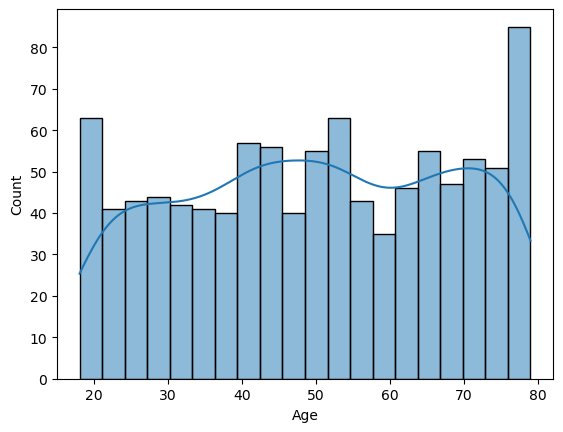

In [13]:
#distribution of age
avg_age=df['Age'].mean()
print('Average age:', avg_age)

sns.histplot(df['Age'], bins=20, kde=True)

Average height: 174.745


<Axes: xlabel='Height_cm', ylabel='Count'>

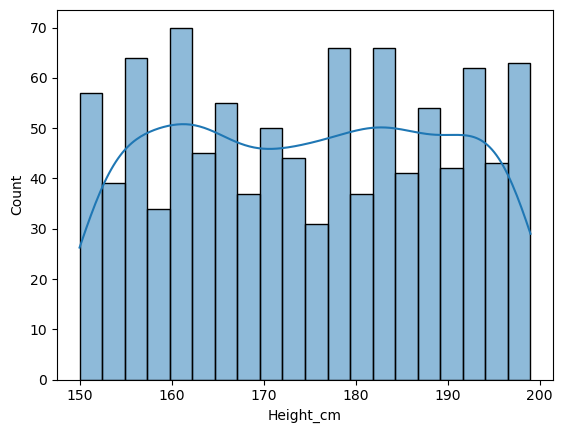

In [14]:
#distribution of height
avg_height=df['Height_cm'].mean()
print('Average height:', avg_height)

sns.histplot(df['Height_cm'], bins=20, kde=True)

Average weight: 49.857


<Axes: xlabel='Weight_kg', ylabel='Count'>

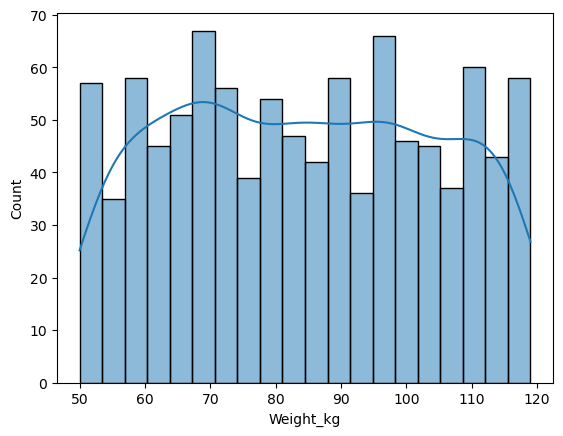

In [15]:
#distribution of weight
avg_weight=df['Weight_kg'].mean()
print('Average weight:', avg_age)

sns.histplot(df['Weight_kg'], bins=20, kde=True)

Average BMI: 26.72951


<Axes: xlabel='BMI', ylabel='Count'>

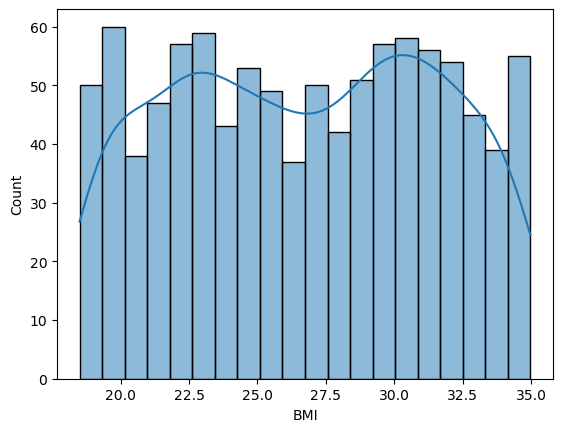

In [16]:
#distribution of weight
avg_bmi=df['BMI'].mean()
print('Average BMI:', avg_bmi)

sns.histplot(df['BMI'], bins=20, kde=True)

Heart Disease Distribution:
 Heart_Disease
No     907
Yes     93
Name: count, dtype: int64


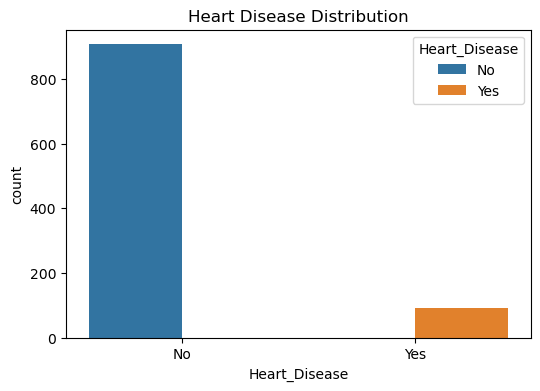

In [17]:
#distribution of heart disease
HD_ratio=df['Heart_Disease'].value_counts()
print('Heart Disease Distribution:\n', HD_ratio)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Heart_Disease', hue= 'Heart_Disease')
plt.title('Heart Disease Distribution')
plt.show()

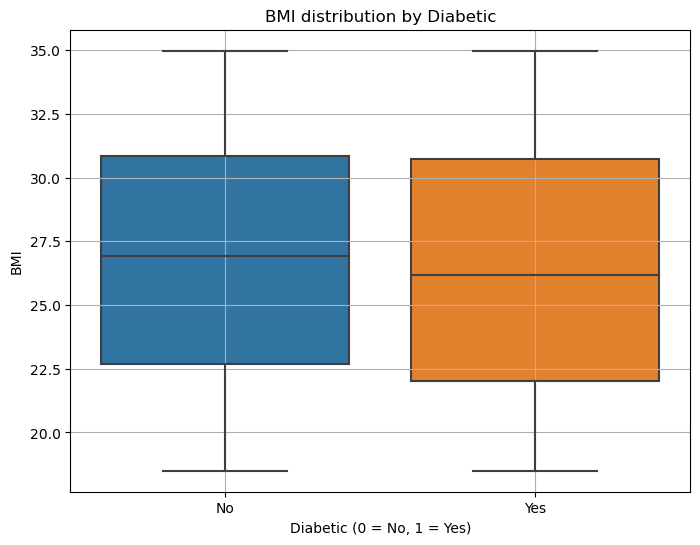

In [18]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Diabetic', y='BMI', data=df)
plt.title('BMI distribution by Diabetic')
plt.xlabel('Diabetic (0 = No, 1 = Yes)')
plt.ylabel('BMI')
plt.grid(True)
plt.show()

Diabetic Distribution:
 Diabetic
No     845
Yes    155
Name: count, dtype: int64


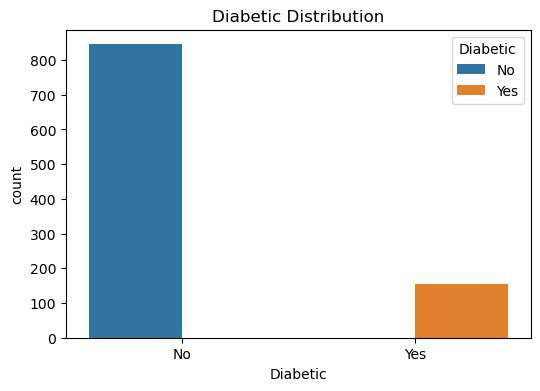

In [23]:
#distribution of diabetes
D_ratio=df['Diabetic'].value_counts()
print('Diabetic Distribution:\n', D_ratio)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Diabetic', hue= 'Diabetic')
plt.title('Diabetic Distribution')
plt.show()

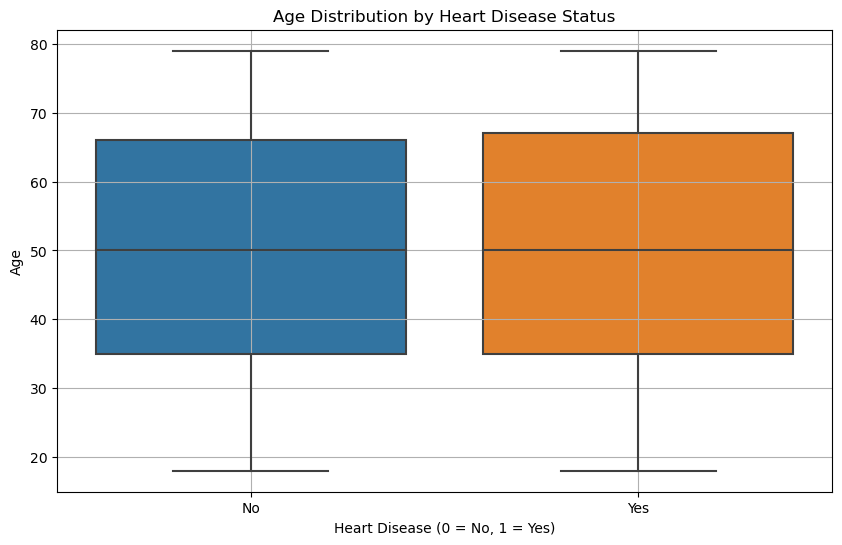

In [24]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Heart_Disease', y='Age', data=df)
plt.title('Age Distribution by Heart Disease Status')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.grid(True)
plt.show()

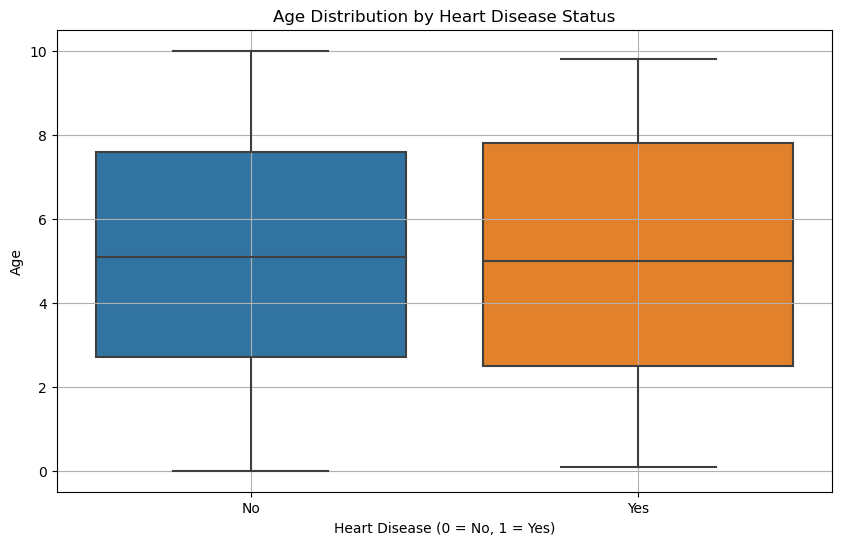

In [25]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Heart_Disease', y='Exercise_Hours_per_Week', data=df)
plt.title('Age Distribution by Heart Disease Status')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.grid(True)
plt.show()

# Prepare Data for Regression Models

In [30]:
# Set X and y, drop ID, BMI, Blood Pressure, Height, and Weight 
X_bmi = df.drop(columns=["ID", "BMI", "Blood_Pressure", "Height_cm", "Weight_kg"])
y_bmi = df["BMI"]

In [31]:
# Encode all categorical variables
X_bmi = pd.get_dummies(X_bmi, drop_first=True)

In [132]:
# Split data into train and test
X_train_bmi, X_test_bmi, y_train_bmi, y_test_bmi = train_test_split(X_bmi, y_bmi, test_size=0.3, random_state=1)

# Linear Model #1: Using almost all variables. No height or BMI

In [135]:
# Initialize adn train linear model
linear_regression = LinearRegression()
linear_regression.fit(X_train_bmi, y_train_bmi)

LinearRegression()

In [137]:
# Predict 
y_pred_bmi = linear_regression.predict(X_test_bmi)
print("Linear Regression Results for BMI:")
print("MAE:", mean_absolute_error(y_test_bmi, y_pred_bmi))
print("MSE:", mean_squared_error(y_test_bmi, y_pred_bmi))
print("R2 Score:", r2_score(y_test_bmi, y_pred_bmi))

Linear Regression Results for BMI:
MAE: 4.08718492126206
MSE: 22.01664846319675
R2 Score: -0.004210243838935979


In [36]:
# Feature importance for coeffecients 
coefficients = pd.DataFrame({
    'Feature': X_bmi.columns,
    'Coefficient': linear_regression.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\nFeature Coefficients (All Features Linear Model):")
print(coefficients)


Feature Coefficients (All Features Linear Model):
                         Feature  Coefficient
8                     Smoker_Yes     0.602795
10             Heart_Disease_Yes     0.177601
3                 Hours_of_Sleep     0.031906
5        Exercise_Hours_per_Week     0.021989
4                     Heart_Rate     0.009019
0                            Age     0.002463
1                    Daily_Steps    -0.000017
2                Calories_Intake    -0.000075
6   Alcohol_Consumption_per_Week    -0.039992
7                    Gender_Male    -0.564453
9                   Diabetic_Yes    -0.688209


In [37]:
#making a prediction using the model
X_bmi.sample()

,Age,Daily_Steps,Calories_Intake,Hours_of_Sleep,Heart_Rate,Exercise_Hours_per_Week,Alcohol_Consumption_per_Week,Gender_Male,Smoker_Yes,Diabetic_Yes,Heart_Disease_Yes
30,50,14757,2650,8.9,70,8.7,5,True,True,False,False


In [38]:
linear_regression.predict([[25,10000,2500,8,60,5,5,0,0,0,0]])

/Users/williammuckler/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([26.72948374])

# Linear Model 2: Using Height & Weight 

In [40]:
# Set new X and y variables for new model
X_hw = df[["Height_cm", "Weight_kg"]]
y_hw = df["BMI"]

In [157]:
# Split data into train and test 
X_train_hw, X_test_hw, y_train_hw, y_test_hw = train_test_split(X_hw, y_hw, test_size=0.3, random_state=1)

In [159]:
# Initialize and train model
linear_regression_hw = LinearRegression()
linear_regression_hw.fit(X_train_hw, y_train_hw)

LinearRegression()

In [161]:
y_pred_hw = linear_regression_hw.predict(X_test_hw)
print("\nLinear Regression Results for BMI (Only Height & Weight):")
print("MAE:", mean_absolute_error(y_test_hw, y_pred_hw))
print("MSE:", mean_squared_error(y_test_hw, y_pred_hw))
print("R2 Score:", r2_score(y_test_hw, y_pred_hw))


Linear Regression Results for BMI (Only Height & Weight):
MAE: 4.070309495151499
MSE: 21.89310009554632
R2 Score: 0.0014249706493879577


In [44]:
# Feature importance for coeffecients 
coefficients = pd.DataFrame({
    'Feature': X_hw.columns,
    'Coefficient': linear_regression_hw.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\nFeature Coefficients (All Features Linear Model):")
print(coefficients)


Feature Coefficients (All Features Linear Model):
     Feature  Coefficient
1  Weight_kg     0.005453
0  Height_cm    -0.007344


In [45]:
#making a prediction using the model
X_hw.sample()

,Height_cm,Weight_kg
93,186,56


In [46]:
linear_regression_hw.predict([[180,0]])

/Users/williammuckler/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([26.23508326])

# Logistic Regression to predict heart disease

In [48]:
# Set X and y, drop ID and Heart Disease
X_hd = df.drop(columns=["ID", "Heart_Disease"])
y_hd = df["Heart_Disease"]

In [49]:
# Encode categorical variables
X_hd = pd.get_dummies(X_hd, drop_first=True)

In [188]:
# Split data
X_train_hd, X_test_hd, y_train_hd, y_test_hd = train_test_split(X_hd, y_hd, test_size=0.3, random_state=2)

In [190]:
# Train model
logr = LogisticRegression(max_iter=10000)
logr.fit(X_train_hd, y_train_hd)

/Users/williammuckler/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=10000)

In [191]:
# Predict and evaluate
y_pred_hd = logr.predict(X_test_hd)

print("\nLogistic Regression Results for Heart Disease:")
print("Accuracy:", accuracy_score(y_test_hd, y_pred_hd))
print("Confusion Matrix:\n", confusion_matrix(y_test_hd, y_pred_hd))
print("Classification Report:\n", classification_report(y_test_hd, y_pred_hd))


Logistic Regression Results for Heart Disease:
Accuracy: 0.9
Confusion Matrix:
 [[270   0]
 [ 30   0]]
Classification Report:
               precision    recall  f1-score   support

          No       0.90      1.00      0.95       270
         Yes       0.00      0.00      0.00        30

    accuracy                           0.90       300
   macro avg       0.45      0.50      0.47       300
weighted avg       0.81      0.90      0.85       300



/Users/williammuckler/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/williammuckler/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/williammuckler/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

# Logistic Regression Using SMOTE

In [ ]:
# pip install imblearn

In [55]:
pip install -U scikit-learn imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [60]:
from imblearn.over_sampling import SMOTE

In [200]:
# Prepare features and target
X_hd = df.drop(columns=["ID", "Heart_Disease"])
y_hd = df["Heart_Disease"]

# Encode categorical variables
X_hd = pd.get_dummies(X_hd, drop_first=True)

# Split into training and testing sets
X_train_hd, X_test_hd, y_train_hd, y_test_hd = train_test_split(X_hd, y_hd, test_size=0.3, random_state=1)

# Apply SMOTE to the training data
smote = SMOTE(random_state=2)
X_train_sm, y_train_sm = smote.fit_resample(X_train_hd, y_train_hd)

# Train the logistic regression model
logr_smote = LogisticRegression(max_iter=1000)
logr_smote.fit(X_train_sm, y_train_sm)

# Predict and evaluate
y_pred_sm = logr_smote.predict(X_test_hd)

print("Logistic Regression (With SMOTE):")
print("Accuracy:", accuracy_score(y_test_hd, y_pred_sm))
print("Confusion Matrix:\n", confusion_matrix(y_test_hd, y_pred_sm))
print("Classification Report:\n", classification_report(y_test_hd, y_pred_sm))

Logistic Regression (With SMOTE):
Accuracy: 0.6566666666666666
Confusion Matrix:
 [[187  83]
 [ 20  10]]
Classification Report:
               precision    recall  f1-score   support

          No       0.90      0.69      0.78       270
         Yes       0.11      0.33      0.16        30

    accuracy                           0.66       300
   macro avg       0.51      0.51      0.47       300
weighted avg       0.82      0.66      0.72       300



/Users/williammuckler/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
